In [2]:
import polars as pl

In [56]:
path = "../output/parquets/val"
cond = "val"

In [58]:
import polars as pl

# 1. Scan the raw data
lf = pl.scan_parquet(f"{path}/1_{cond}_data.parquet")

# 2. Define the cleaning plan
exclude = ['Timestamp', 'Label']
numeric_cols = [col for col in lf.columns if col not in exclude]

# 3. Apply cleaning AND the sink in one go
(
    lf.with_columns([
        pl.col(numeric_cols).cast(pl.Float64, strict=False)
    ])
    .sink_parquet(f"{path}/2_{cond}_data_str_handled.parquet")
)

print(" Cleaned without any manual batching errors!")

C:\Users\akhiz\AppData\Local\Temp\ipykernel_9960\853739354.py:8: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  numeric_cols = [col for col in lf.columns if col not in exclude]


 Cleaned without any manual batching errors!


In [59]:
import polars as pl

input_path = f"{path}/2_{cond}_data_str_handled.parquet"

# 1. Eagerly load into memory
test = pl.read_parquet(input_path)

print("Unique values in Label column:")
print(test.get_column("Label").value_counts())

# 2. Filter out the rogue CSV headers
test = test.filter(pl.col("Label") != "Label")

print(f"Final shape: {test.shape}")

# 3. Write back to disk using the eager method
test.write_parquet(input_path)
print("File successfully overwritten.")

Unique values in Label column:
shape: (15, 2)
┌──────────────────────────┬────────┐
│ Label                    ┆ count  │
│ ---                      ┆ ---    │
│ str                      ┆ u32    │
╞══════════════════════════╪════════╡
│ DoS attacks-SlowHTTPTest ┆ 13989  │
│ Label                    ┆ 7      │
│ SQL Injection            ┆ 10     │
│ DDOS attack-LOIC-UDP     ┆ 173    │
│ DoS attacks-Hulk         ┆ 46192  │
│ …                        ┆ …      │
│ Brute Force -Web         ┆ 62     │
│ Bot                      ┆ 28620  │
│ FTP-BruteForce           ┆ 19336  │
│ Benign                   ┆ 611216 │
│ DoS attacks-Slowloris    ┆ 1100   │
└──────────────────────────┴────────┘
Final shape: (828430, 80)
File successfully overwritten.


In [60]:
import polars as pl

# --- CONFIGURATION ---
input_path = f"{path}/2_{cond}_data_str_handled.parquet"
output_path = f"{path}/5_{cond}_data_optimized.parquet"

print("=" * 80)
print("POLARS: STREAMING FEATURE SELECTION & OPTIMIZATION")
print("=" * 80)

# 1. Scan the data to get available columns (Lazy, no RAM used)
lf = pl.scan_parquet(input_path)
available_columns = lf.columns

# =============================================================
# STEP 1: KEEP ONLY IMPORTANT FEATURES
# =============================================================
important_features = [
    'Timestamp', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol',
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s',
    'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Mean', 'Pkt Len Var', 'Pkt Len Std',
    'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std',
    'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Active Mean', 'Idle Mean', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Down/Up Ratio', 'Label'
]

# Ensure we only try to keep columns that actually exist in the file
keep_cols = [c for c in important_features if c in available_columns]
print(f"Selecting {len(keep_cols)} key features (Discarding the rest)")

# Identify categorical candidates dynamically
cat_candidates = [c for c in ['Protocol', 'Label'] if c in keep_cols]

# =============================================================
# STEP 2: BUILD THE OPTIMIZATION PLAN
# =============================================================
# THE FIX: Chain with_columns sequentially to avoid parallel assignment conflicts
optimized_lf = (
    lf.select(keep_cols)
    # Phase A: Downcast all numeric columns
    .with_columns([
        pl.col(pl.Float64).cast(pl.Float32),
        pl.col(pl.Int64).cast(pl.Int32),
    ])
    # Phase B: Convert specific columns to Categorical (Overwrites Phase A if needed)
    .with_columns([
        pl.col(cat_candidates).cast(pl.String).cast(pl.Categorical),
    ])
)

# Optional: Handle Timestamp safely if it exists
if 'Timestamp' in keep_cols:
    optimized_lf = optimized_lf.with_columns([
        pl.col('Timestamp').str.to_datetime(strict=False)
    ])

# =============================================================
# STEP 3: EXECUTE & SINK
# =============================================================
print("Processing and saving optimized dataset...")
optimized_lf.sink_parquet(output_path)

# =============================================================
# STEP 4: FINAL MEMORY REPORT
# =============================================================
df_final = pl.read_parquet(output_path)
mem_mb = df_final.estimated_size() / (1024 ** 2)

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE")
print("=" * 80)
print(f"Final Shape: {df_final.shape}")
print(f"RAM footprint in Polars: {mem_mb:.2f} MB")

POLARS: STREAMING FEATURE SELECTION & OPTIMIZATION
Selecting 29 key features (Discarding the rest)
Processing and saving optimized dataset...


C:\Users\akhiz\AppData\Local\Temp\ipykernel_9960\3051571597.py:13: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  available_columns = lf.columns



OPTIMIZATION COMPLETE
Final Shape: (828430, 29)
RAM footprint in Polars: 94.81 MB


In [71]:
import polars as pl

print("Starting minimal feature engineering...")
# Assuming you loaded your data eagerly for notebook exploration:
df = pl.read_parquet(f"{path}/5_{cond}_data_optimized.parquet")



Starting minimal feature engineering...


In [72]:
# ===== CELL 3: CLUSTER 1 - Traffic Balance (4 features) =====
"""
PURPOSE: Detect asymmetric communication patterns
- DDoS floods show extreme imbalance (many packets one way)
- Port scans have minimal responses
- Normal traffic is usually more balanced
"""
# We define total_pkts as a Polars expression for reuse
total_pkts_expr = pl.col('Tot Fwd Pkts') + pl.col('Tot Bwd Pkts')

df = df.with_columns([
    (pl.col('Tot Fwd Pkts') / (pl.col('Tot Bwd Pkts') + 1)).alias('fwd_bwd_pkt_ratio'),
    
    # min_horizontal replaces np.minimum
    pl.min_horizontal(
        pl.col('Tot Fwd Pkts') / (total_pkts_expr + 1),
        pl.col('Tot Bwd Pkts') / (total_pkts_expr + 1)
    ).alias('traffic_symmetry'),
    
    (pl.col('Tot Bwd Pkts') / (pl.col('Tot Fwd Pkts') + 1)).alias('response_ratio'),
    
    ((pl.col('Tot Fwd Pkts') > 0) & (pl.col('Tot Bwd Pkts') > 0)).cast(pl.Int32).alias('bidirectional_active')
])

print("Cluster 1: Traffic Balance (4 features added)")



Cluster 1: Traffic Balance (4 features added)


In [73]:
# ===== CELL 4: CLUSTER 2 - Temporal Patterns (3 features) =====
"""
PURPOSE: Identify abnormal timing patterns
- Automated attacks have very regular/irregular intervals
- Flooding attacks have extremely short intervals
- Normal traffic has natural variation
"""
df = df.with_columns([
    (pl.col('Flow IAT Std') / (pl.col('Flow IAT Mean') + 1)).alias('iat_regularity'),
    (total_pkts_expr / (pl.col('Flow Duration') + 0.001)).alias('flow_rate'),
    (pl.col('Fwd IAT Mean') - pl.col('Bwd IAT Mean')).abs().alias('timing_asymmetry')
])

print("Cluster 2: Temporal Patterns (3 features added)")



Cluster 2: Temporal Patterns (3 features added)


In [74]:
# ===== CELL 5: CLUSTER 3 - Packet Size Patterns (3 features) =====
"""
PURPOSE: Detect abnormal payload characteristics
- Many attacks use fixed-size packets (low variance)
- Scans often use minimal packets
- Exfiltration may show unusual size distributions
"""
df = df.with_columns([
    (pl.col('Pkt Len Std') / (pl.col('Pkt Len Mean') + 1)).alias('pkt_size_variance'),
    (pl.col('Fwd Pkt Len Mean') - pl.col('Bwd Pkt Len Mean')).abs().alias('fwd_bwd_size_diff'),
    (pl.col('Pkt Len Mean') < 100).cast(pl.Int32).alias('is_small_packet')
])

print("Cluster 3: Packet Size Patterns (3 features added)")



Cluster 3: Packet Size Patterns (3 features added)


In [75]:
# ===== CELL 6: CLUSTER 4 - Port Risk Indicators (3 features) =====
"""
PURPOSE: Flag potentially risky or unusual port usage
- Attacks often target specific vulnerable ports
- Ephemeral ports may indicate C&C communication
- Well-known ports have different risk profiles
"""
risky_ports = [21, 22, 23, 25, 445, 3389, 1433, 3306] 
web_ports = [80, 443, 8080, 8443]

df = df.with_columns([
    pl.col('Dst Port').is_in(risky_ports).cast(pl.Int32).alias('is_risky_port'),
    pl.col('Dst Port').is_in(web_ports).cast(pl.Int32).alias('is_web_traffic'),
    
    # pl.when().then() replaces pd.cut() for much faster binning
    pl.when(pl.col('Dst Port') <= 1024).then(0)
      .when(pl.col('Dst Port') <= 49151).then(1)
      .otherwise(2).alias('port_category')
])

print("Cluster 4: Port Risk Indicators (3 features added)")



Cluster 4: Port Risk Indicators (3 features added)


In [76]:
# ===== CELL 7: CLUSTER 5 - Composite Anomaly Score (1 feature) =====
"""
PURPOSE: Single metric combining multiple attack indicators
- High score = multiple suspicious characteristics present
- Useful for quick filtering and threshold-based detection
"""
df = df.with_columns([
    (
        (pl.col('traffic_symmetry') < 0.1).cast(pl.Int32) + 
        pl.col('is_small_packet') +  # Already Int32 from Cluster 3
        (pl.col('flow_rate') > pl.col('flow_rate').quantile(0.95)).cast(pl.Int32) + 
        (pl.col('iat_regularity') < 0.05).cast(pl.Int32) + 
        pl.col('is_risky_port')      # Already Int32 from Cluster 4
    ).alias('anomaly_score')
])

print("Cluster 5: Composite Anomaly Score (1 feature added)")



Cluster 5: Composite Anomaly Score (1 feature added)


In [77]:
df.shape

(828430, 43)

In [78]:


# ===== CELL 9 (Optional): Save Dataset =====
df.write_parquet(f"{path}/6_{cond}_feature_engineered.parquet")
print("Dataset saved!")

Dataset saved!


In [79]:
import polars as pl
import polars.selectors as cs



print("\n" + "="*60)
print("PREPARING DATA FOR TRAINING")
print("="*60)

df = pl.read_parquet(f"{path}/6_{cond}_feature_engineered.parquet")

# Extract useful features from Timestamp if it exists
if 'Timestamp' in df.columns:
    print("Extracting temporal features from Timestamp...")
    
    # Ensure Timestamp is a datetime type before extracting features
    time_col = pl.col('Timestamp')
    if df.schema['Timestamp'] == pl.String:
        time_col = time_col.str.to_datetime(strict=False)
        
    df = df.with_columns([
        time_col.dt.hour().alias('hour'),
        # Polars weekday is 1(Mon)-7(Sun). We subtract 1 to match Pandas 0-6 format.
        (time_col.dt.weekday() - 1).alias('day_of_week')
    ]).with_columns([
        # Now we can safely calculate weekend and business hours
        (pl.col('day_of_week') >= 5).cast(pl.Int32).alias('is_weekend'),
        ((pl.col('hour') >= 9) & (pl.col('hour') <= 17)).cast(pl.Int32).alias('is_business_hours')
    ])
    
    # Fill any nulls generated by invalid timestamps with 0 to prevent ML crashes
    df = df.with_columns([
        pl.col(['hour', 'day_of_week', 'is_weekend', 'is_business_hours']).fill_null(0)
    ])
    print("  Added: hour, day_of_week, is_weekend, is_business_hours")

# Drop non-numeric columns that can't be used for training
cols_to_drop = ['Label', 'Timestamp']



# Separate target from features
X = df.drop(cols_to_drop)

# In Polars, we use get_column to extract a Series. 
# Polars Series are immutable, so we don't need a .copy() like in Pandas.
y = df.get_column('Label')

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Number of features: {X.shape[1]}")


PREPARING DATA FOR TRAINING
Extracting temporal features from Timestamp...
  Added: hour, day_of_week, is_weekend, is_business_hours

Features (X): (828430, 45)
Target (y): (828430,)
Number of features: 45


In [80]:
X.write_parquet(f"{path}/7_X_{cond}.parquet")

# Convert the Series to a DataFrame, then save
y.to_frame().write_parquet(f"{path}/8_y_{cond}.parquet")

In [81]:
# encode protocol using model from 1_ohe_feature_encoder.pkl
import polars as pl
import joblib

print("="*60)
print("STATEFUL ML ENCODING (APPLYING TO TEST DATA)")
print("="*60)

# =============================================================
# 1. LOAD TEST DATA
# =============================================================
# Update these paths to point to your actual test parquet files
X_test = pl.read_parquet(f"{path}/7_X_{cond}.parquet")
y_test = pl.read_parquet(f"{path}/8_y_{cond}.parquet").get_column('Label')

# =============================================================
# 2. LOAD SAVED ENCODERS
# =============================================================
print("Loading saved encoder objects...")
ohe = joblib.load('..//output//downloads//encoders//1_ohe_feature_encoder.pkl')
le = joblib.load('..//output//downloads//encoders//2_target_label_encoder.pkl')

# =============================================================
# 3. APPLY ONE-HOT ENCODER (FEATURES)
# =============================================================
# Extract the exact column names the OHE was trained on to prevent train/test skew
categorical_cols = list(ohe.feature_names_in_)

if categorical_cols:
    print(f"Applying OneHotEncoder to: {categorical_cols}")
    
    # We use .transform() here, NEVER .fit_transform()
    # Unseen categories will safely be encoded as all 0s due to handle_unknown='ignore'
    encoded_array = ohe.transform(X_test.select(categorical_cols).to_pandas())
    
    # Rebuild the Polars DataFrame with the new OHE columns
    feature_names = ohe.get_feature_names_out(categorical_cols)
    encoded_pl = pl.DataFrame(encoded_array, schema=list(feature_names))
    
    # Drop old string columns and horizontally concatenate the new one-hot columns
    X_test = pl.concat([X_test.drop(categorical_cols), encoded_pl], how="horizontal")
    print(f" Final Test Feature Shape: {X_test.shape}")

# =============================================================
# 4. APPLY LABEL ENCODER (TARGET)
# =============================================================
print("\nApplying LabelEncoder to Target...")

# NOTE: If your test set contains a brand new attack type not seen in training, 
# le.transform() will throw a ValueError. 

y_test_encoded_array = le.transform(y_test.to_numpy())
y_test_encoded = pl.Series("Label", y_test_encoded_array)
print("Target encoding successful.")


print("\nEncoding complete. Ready for model inference.")

# (Optional) Save the fully encoded test data
X_test.write_parquet(f"{path}/9_X_{cond}_encoded.parquet")
y_test_encoded.to_frame().write_parquet(f"{path}/10_y_{cond}_encoded.parquet")

STATEFUL ML ENCODING (APPLYING TO TEST DATA)
Loading saved encoder objects...
Applying OneHotEncoder to: ['Protocol']
 Final Test Feature Shape: (828430, 47)

Applying LabelEncoder to Target...
Target encoding successful.

Encoding complete. Ready for model inference.


In [68]:
# print all unique values of y_test
list(y_test.unique())

['DoS attacks-Hulk',
 'Benign',
 'Bot',
 'SSH-Bruteforce',
 'DoS attacks-GoldenEye',
 'Brute Force -Web',
 'Brute Force -XSS',
 'SQL Injection',
 'DoS attacks-Slowloris',
 'FTP-BruteForce',
 'Infilteration',
 'DDOS attack-HOIC',
 'DDOS attack-LOIC-UDP',
 'DoS attacks-SlowHTTPTest']

In [82]:
import polars as pl

print("\nCleaning data...")

X = pl.read_parquet(f"{path}/9_X_{cond}_encoded.parquet")
y = pl.read_parquet(f"{path}/10_y_{cond}_encoded.parquet").get_column('Label')
# 1. Identify floating-point columns
# Integers and Strings cannot legally hold Inf or NaN, so we skip them to save processing time.
float_cols = [
    col for col, dtype in X.schema.items() 
    if dtype in [pl.Float32, pl.Float64]
]

if float_cols:
    # 2. Count how many invalid values exist across the entire DataFrame
    # This checks for Inf, -Inf, NaN, and Null simultaneously
    invalid_check = X.select([
        (pl.col(c).is_infinite() | pl.col(c).is_nan() | pl.col(c).is_null()).sum().alias(c)
        for c in float_cols
    ])
    
    # Sum the results of all columns to get the grand total
    total_invalid = sum(invalid_check.row(0))
    
    if total_invalid > 0:
        print(f"  Found {total_invalid} invalid values (Inf/NaN/Null) - filling with 0")
        
        # 3. Apply the cleaning transformation in parallel
        # We flag Infinities and NaNs, convert them to Null, and then fill all Nulls with 0.0
        X = X.with_columns([
            pl.when(pl.col(c).is_infinite() | pl.col(c).is_nan())
            .then(None)
            .otherwise(pl.col(c))
            .fill_null(0.0)
            .alias(c)
            for c in float_cols
        ])
    else:
        print("  No invalid values found.")

print("Data cleaned")


Cleaning data...
  Found 6750 invalid values (Inf/NaN/Null) - filling with 0
Data cleaned


In [83]:
# import standard scaler
import polars as pl
import numpy as np
import joblib

print("="*60)
print("STANDARD SCALING (APPLYING TO TEST DATA)")
print("="*60)

# =============================================================
# 1. LOAD THE FITTED SCALER
# =============================================================
print("Loading saved StandardScaler...")
scaler = joblib.load('..//output//downloads//encoders//3_standard_scaler.pkl')

# =============================================================
# 2. ALIGN AND PREPARE TEST DATA
# =============================================================
# Store feature names to rebuild the DataFrame later
feature_names = X_test.columns

print("Converting test data to 32-bit array for memory safety...")
# Cast to numpy float32 to prevent Scikit-Learn from upcasting to 64-bit and spiking RAM
X_numpy_32 = X.to_numpy().astype(np.float32)

# =============================================================
# 3. APPLY SCALING TRANSFORMATION
# =============================================================
print("Transforming test data using training metrics...")
# VERY IMPORTANT: Use .transform(), NEVER .fit_transform() here
X_scaled_array = scaler.transform(X_numpy_32)

# =============================================================
# 4. RECONSTRUCT POLARS DATAFRAME
# =============================================================
# Rebuild the DataFrame and explicitly keep it as Float32
X_test = pl.DataFrame(X_scaled_array, schema=feature_names).select(
    pl.all().cast(pl.Float32)
)

print(f"Standard Scaling complete. Final test feature matrix shape: {X_test.shape}")

# Verify memory usage
mem_mb = X_test.estimated_size() / (1024 ** 2)
print(f"RAM footprint in Polars: {mem_mb:.2f} MB")

# (Optional) Save the final, fully processed test arrays for model inference
# X_test.write_parquet("..//output//paquets//test//11_X_test_final.parquet")

STANDARD SCALING (APPLYING TO TEST DATA)
Loading saved StandardScaler...
Converting test data to 32-bit array for memory safety...
Transforming test data using training metrics...
Standard Scaling complete. Final test feature matrix shape: (828430, 47)
RAM footprint in Polars: 148.53 MB


In [84]:
X_test.write_parquet(f"{path}/11_X_{cond}_scaled.parquet")

In [86]:
import numpy as np
import xgboost as xgb
import joblib
from sklearn.metrics import classification_report, confusion_matrix

path = "../output/parquets/test"
cond = "test"
print("="*60)
print("MODEL EVALUATION: TRAINING DATA SANITY CHECK")
print("="*60)

# 1. Load the Label Encoder for human-readable class names
print("Loading label encoder...")
le = joblib.load('..//output//downloads//encoders//2_target_label_encoder.pkl')
class_names = le.classes_

# 2. Load the Training Data
print("Loading training data matrices...")
X_eval = pl.read_parquet(f"{path}/11_X_{cond}_scaled.parquet")
y_eval = pl.read_parquet(f"{path}/10_y_{cond}_encoded.parquet").get_column('Label')

# 3. Load the Trained Model
print("Loading trained XGBoost model...")
model = xgb.XGBClassifier()
model.load_model("../output/downloads/models/xgboost_ids_model.json")

# 4. Generate Predictions
print("Generating predictions on training data...")
y_pred = model.predict(X_eval)

# 5. Print Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TRAINING SET)")
print("="*60)
# digits=4 gives you precision up to 4 decimal places, great for academic reporting
report = classification_report(y_eval, y_pred, target_names=class_names, digits=4)
print(report)

# 6. Print Confusion Matrix
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(y_eval, y_pred)
print(cm)

MODEL EVALUATION: TRAINING DATA SANITY CHECK
Loading label encoder...
Loading training data matrices...
Loading trained XGBoost model...
Generating predictions on training data...

CLASSIFICATION REPORT (TRAINING SET)
                          precision    recall  f1-score   support

                  Benign     0.9773    0.7313    0.8366   1222430
                     Bot     0.9999    1.0000    1.0000     57238
        Brute Force -Web     0.1322    0.9836    0.2330       122
        Brute Force -XSS     0.7541    1.0000    0.8598        46
        DDOS attack-HOIC     1.0000    1.0000    1.0000    137202
    DDOS attack-LOIC-UDP     1.0000    1.0000    1.0000       346
   DoS attacks-GoldenEye     0.9941    0.9987    0.9964      8301
        DoS attacks-Hulk     1.0000    1.0000    1.0000     92382
DoS attacks-SlowHTTPTest     1.0000    1.0000    1.0000     27978
   DoS attacks-Slowloris     0.9941    1.0000    0.9971      2198
          FTP-BruteForce     0.9998    1.0000    0.9999

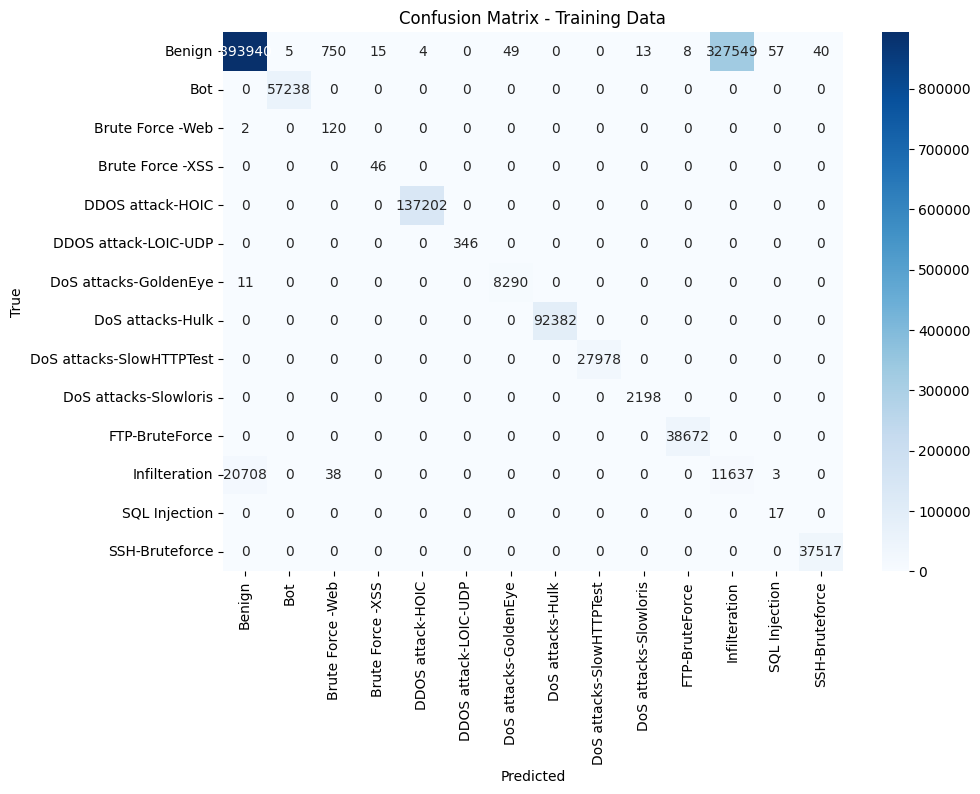

In [54]:
# visualize confusion matrix with class names
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Training Data')
plt.show()